In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [42]:
df_raw = pd.read_csv("anime.csv")

In [43]:
df = df_raw.copy()

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    10000 non-null  int64  
 1   title       10000 non-null  object 
 2   score       10000 non-null  float64
 3   rank        10000 non-null  int64  
 4   popularity  10000 non-null  int64  
 5   members     10000 non-null  int64  
 6   synopsis    9998 non-null   object 
 7   start_date  9998 non-null   object 
 8   end_date    9916 non-null   object 
 9   type        10000 non-null  object 
 10  episodes    9952 non-null   float64
 11  image_url   10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [45]:
df.describe()

,anime_id,score,rank,popularity,members,episodes
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,9952.000000
mean,24129.128000,6.980589,5000.494000,6490.903700,1.075309e+05,15.702271
std,19948.188153,0.619406,2886.898727,4646.309341,2.733514e+05,41.865696
min,1.000000,6.050000,1.000000,1.000000,2.260000e+02,1.000000
25%,4055.500000,6.470000,2500.750000,2591.750000,4.270250e+03,1.000000
50%,21406.000000,6.900000,5000.500000,5564.500000,1.817900e+04,11.000000
75%,40028.750000,7.390000,7500.250000,9824.250000,8.469275e+04,13.000000
max,62863.000000,9.290000,10000.000000,22184.000000,4.262220e+06,1787.000000


In [31]:
df.head()

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...


In [46]:
df.tail()

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
9995,1351,Angel Cop,6.05,9994,4755,26983,"Sometime in the future, terrorism in Japan has...",1989-01-01,1994-01-01,OVA,6.0,https://cdn.myanimelist.net/images/anime/1377/...
9996,33339,Zhongguo Jingqi Xiansheng,6.05,9991,10781,3192,A lost form of magic is revived from the Easte...,2014-01-01,2016-01-01,ONA,63.0,https://cdn.myanimelist.net/images/anime/1637/...
9997,2840,Youkoso Lodoss-tou e!,6.05,9988,11348,2710,This movie is the compilation of the 27 mini-p...,1998-01-01,1998-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/7/613...
9998,33764,Ying Xiong Bie Nao,6.05,9987,17963,502,The series takes place on a parallel world fil...,2015-01-01,2015-01-01,ONA,13.0,https://cdn.myanimelist.net/images/anime/1013/...
9999,49700,Arifureta Shokugyou de Sekai Saikyou Picture D...,6.05,9996,10448,3510,An online motion graphic spin-off series that ...,2019-01-01,2019-01-01,ONA,13.0,https://cdn.myanimelist.net/images/anime/1169/...


In [47]:
df.isnull().sum()

anime_id       0
title          0
score          0
rank           0
popularity     0
members        0
synopsis       2
start_date     2
end_date      84
type           0
episodes      48
image_url      0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(1)

In [49]:
df = df.drop_duplicates().copy()

In [50]:
df = df.dropna(subset="episodes").copy()

In [59]:
df.isnull().sum()


anime_id       0
title          0
score          0
rank           0
popularity     0
members        0
synopsis       2
start_date     2
end_date      36
type           0
episodes       0
image_url      0
dtype: int64

In [60]:
df = df.dropna(subset=["start_date","synopsis"]).copy()

In [63]:
df["end_date"] = pd.to_datetime(df["end_date"] , format="mixed" , errors="coerce")

In [64]:
df["start_date"] = pd.to_datetime(df["start_date"] , format="mixed" , errors="coerce") 

In [72]:
df

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1351,Angel Cop,6.05,9994,4755,26983,"Sometime in the future, terrorism in Japan has...",1989-01-01,1994-01-01,OVA,6.0,https://cdn.myanimelist.net/images/anime/1377/...
9996,33339,Zhongguo Jingqi Xiansheng,6.05,9991,10781,3192,A lost form of magic is revived from the Easte...,2014-01-01,2016-01-01,ONA,63.0,https://cdn.myanimelist.net/images/anime/1637/...
9997,2840,Youkoso Lodoss-tou e!,6.05,9988,11348,2710,This movie is the compilation of the 27 mini-p...,1998-01-01,1998-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/7/613...
9998,33764,Ying Xiong Bie Nao,6.05,9987,17963,502,The series takes place on a parallel world fil...,2015-01-01,2015-01-01,ONA,13.0,https://cdn.myanimelist.net/images/anime/1013/...


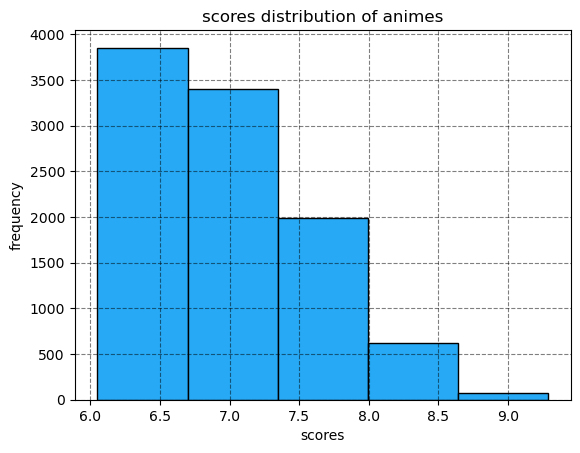

In [82]:
plt.hist(df["score"] ,bins=5 ,edgecolor="black",color="#27A9F5")
plt.title("scores distribution of animes")
plt.xlabel("scores")
plt.ylabel("frequency")
plt.grid(True , linestyle="--" , alpha=0.5 ,color="black")

plt.show()

In [84]:
total_scores_by_type = df.groupby("type")["score"].sum()

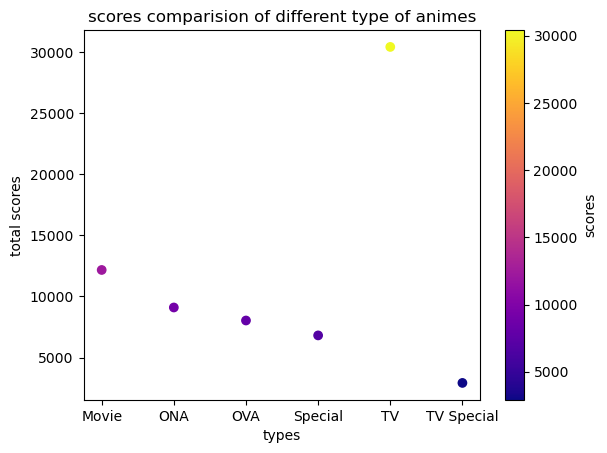

In [94]:
plt.scatter(total_scores_by_type.index ,
            total_scores_by_type.values,
            c=total_scores_by_type.values,
            cmap="plasma")
plt.colorbar(label="scores")
plt.title("scores comparision of different type of animes")
plt.xlabel("types")
plt.ylabel("total scores")
plt.show()